### CorEx for anchored model topics with relevant seed-words
#robust seed version (see: PreTreatment\env_topics)

In [8]:
#all required imports

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from corextopic import corextopic as ct

In [2]:
# robust seed topics for CorEx from: OriginalDataSets\env_topics.py

topics = {
    "Manufacturing of low-carbon technologies": [
        "low-carbon technology manufacturing", "renewable energy equipment", "mitigation equipment", "energy-saving appliances",
        "clean-tech production", "photovoltaic module assembly", "wind turbine manufacturing", "EU Ecolabel",
        "Ecodesign Directive", "Energy Star", "IRENA", "SolarPower Europe",
        "technological lock-in", "subsidy dependence", "industrial competitiveness", "carbon leakage",
        "green industrial policy"
    ],

    "Energy efficiency in industrial processes": [
        "industrial energy performance", "heat recovery systems", "energy intensity reduction", "process optimization",
        "energy audits", "industrial thermal regulation", "high-efficiency motors", "ISO 50001",
        "ESCO", "IEA Industrial Energy", "Energy Efficiency First", "European Energy Efficiency Platform",
        "rebound effect", "abatement costs", "stranded industrial assets", "implementation gap",
        "investment barriers"
    ],

    "Circular material flows and material efficiency": [
        "circular material flows", "secondary raw materials", "design for disassembly", "material substitution",
        "by-product utilization", "remanufacturing processes", "industrial symbiosis", "Circular Economy Action Plan",
        "Waste Framework Directive", "Ellen MacArthur Foundation", "REACH regulation", "Cradle to Cradle",
        "downcycling", "recycling toxicity", "planned obsolescence", "waste trade",
        "recycled content claims"
    ],

    "Carbon Capture, Utilization, and Storage (CCU/CCS)": [
        "carbon capture storage", "geological sequestration", "direct air capture", "BECCS",
        "CCU technologies", "post-combustion capture", "underground storage integrity", "Global CCS Institute",
        "London Protocol", "CCS Directive", "Northern Lights Project", "IEA GHG",
        "unabated fossil fuels", "storage leakage risk", "moral hazard", "high operational cost",
        "CCS greenwashing"
    ],

    "Fuel switching and industrial electrification": [
        "industrial electrification", "low-emission hydrogen", "green ammonia", "industrial fuel switching",
        "electric arc furnaces", "synthetic kerosene", "industrial gas-to-power", "Hydrogen Council",
        "Power-to-X", "IPHE", "Green Hydrogen Catapult", "Clean Hydrogen Partnership",
        "hydrogen leakage", "grid capacity", "energy density", "hydrogen greenwashing",
        "electrification costs"
    ],

    "Sustainable mining for transition materials": [
        "critical minerals extraction", "lithium extraction", "rare earth elements", "tailings management",
        "mineral waste prevention", "deep-sea mining", "resource depletion", "Critical Raw Materials Act",
        "ICMM", "Responsible Mining Foundation", "OECD Mineral Guidelines", "Deep Sea Conservation Coalition",
        "habitat fragmentation", "resource curse", "indigenous land rights", "toxic tailings spill",
        "transition mineral rush"
    ],

    "Road transport electrification and battery technology": [
        "electric vehicles", "lithium-ion batteries", "charging infrastructure", "zero-emission vehicles",
        "vehicle-to-grid", "battery energy density", "liquid electrolyte", "IEA-STEPS",
        "Euro 7 standard", "International Energy Agency", "European Battery Alliance", "Global Battery Alliance",
        "range anxiety", "critical minerals", "battery resource footprint", "grid stability",
        "lithium scarcity"
    ],

    "Sustainable aviation and maritime fuels": [
        "sustainable aviation fuels", "maritime decarbonization", "green ammonia", "synthetic kerosene",
        "low-emission hydrogen", "alternative energy carriers", "e-fuels", "CORSIA",
        "International Maritime Organization", "ICAO", "Clean Skies for Tomorrow", "Getting to Zero Coalition",
        "hard-to-abate residual emissions", "high operational cost", "feedstock availability", "technological maturity",
        "fuel-vs-food trade-off"
    ],

    "Public transit and active mobility systems": [
        "active mobility", "public transport expansion", "bus rapid transit", "cycling infrastructure",
        "walkable cities", "transit-oriented development", "shared mobility", "SDG 11.2",
        "C40 Cities", "International Association of Public Transport", "Walk21", "Institute for Transportation and Development Policy",
        "car-free zones", "infrastructure investment gap", "transit equity", "urban accessibility",
        "modal shift barriers"
    ],

    "Transport infrastructure and habitat fragmentation": [
        "habitat fragmentation", "linear infrastructure", "wildlife corridors", "ecosystem connectivity",
        "paved road length", "barrier effects", "infrastructure expansion", "Convention on Migratory Species",
        "IUCN", "Global Road Map", "Infrastructures and Ecology Network Europe", "Trans-European Transport Network",
        "land grabbing", "population displacement", "environmental social costs", "unprecedented expansion",
        "illegal logging access"
    ],

    "Freight modal shift and logistics optimization": [
        "modal shift", "freight electrification", "rail logistics", "intermodal transport",
        "supply chain efficiency", "heavy-duty trucks", "logistics optimization", "Shift2Rail",
        "Eurostat Freight", "European Rail Freight Association", "International Transport Forum", "World Road Association",
        "infrastructure bottlenecks", "cross-border interoperability", "last-mile delivery", "speed-of-delivery trade-offs",
        "regulatory barriers"
    ],

    "Tourism-related transportation and carbon footprint": [
        "tourism carbon footprint", "travel-related emissions", "long-distance transportation", "seaborne travel pollution",
        "airborne travel emissions", "ecotourism scale", "UNWTO", "Sustainable Tourism Global Council",
        "SDG 8.9", "SDG 12.b", "Global Sustainable Tourism Council", "flight shaming",
        "overtourism", "invasive alien species pathway", "carbon leakage", "tourism dependency"
    ],

    "Deep energy retrofitting and thermal performance": [
        "building retrofitting", "thermal insulation", "HVAC optimization", "energy performance certificates",
        "building envelope improvement", "smart thermal regulation", "deep renovation", "Energy Performance of Buildings Directive",
        "EPBD", "Renovation Wave", "Eurostat Energy Efficiency", "Energy Star",
        "split incentives", "retrofit rate", "up-front investment cost", "housing affordability",
        "gentrification risk"
    ],

    "Zero-emission building design and construction": [
        "zero-emission buildings", "passive house design", "onsite renewable energy", "low-emissions heating",
        "net-zero housing", "sustainable building standards", "low-carbon construction", "EU Green Building",
        "LEED certification", "BREEAM", "World Green Building Council", "Ecodesign Directive",
        "construction cost premium", "embodied carbon debate", "regulatory compliance burden", "net-zero greenwashing",
        "building lifespan"
    ],

    "Circularity and building material reuse": [
        "building material reuse", "disassembly and deconstruction", "circular material flows", "construction waste prevention",
        "repurposing buildings", "secondary building materials", "material recovery", "Waste Framework Directive",
        "Circular Economy Action Plan", "REACH regulation", "Cradle to Cradle", "EMAS",
        "structural safety concerns", "toxic legacy materials", "downcycling", "demolition waste dumping",
        "waste trade"
    ],

    "Low-carbon material substitution (Bio-based materials)": [
        "bio-based materials", "sustainably sourced wood", "long-lived wood products", "construction material substitution",
        "engineered timber", "natural building materials", "carbon sequestration in products", "FSC certification",
        "PEFC", "FLEGT", "EU Timber Regulation", "Nagoya Protocol",
        "carbon sink integrity", "harvesting rates", "land-use competition", "forest degradation risk",
        "biomass sustainability"
    ],

    "Sufficiency and demand management in built environments": [
        "sufficiency measures", "demand-side mitigation", "floor area per capita", "co-housing models",
        "resource-efficient lifestyles", "urban density management", "avoid-shift-improve", "IPCC WGIII",
        "SDG 12.1", "10-Year Framework of Programmes", "C40 Cities", "UN-Habitat",
        "living standards conflict", "lifestyle changes", "degrowth debate", "personal freedom",
        "urban sprawl"
    ],

    "Climate adaptation and resilient building infrastructure": [
        "climate resilient development", "disaster risk management", "urban heat island mitigation", "flood-resilient housing",
        "building adaptation solutions", "thermal regulation", "early warning systems", "Sendai Framework",
        "Global Adaptation Network", "United Nations-supported Principles for Responsible Investment", "Green Climate Fund", "maladaptation",
        "seawall lock-in", "inequitable protection", "vulnerability transition", "relocation risks"
    ],

    "Compact urban form and land-use planning": [
        "compact urban form", "job-housing co-location", "urban urbanization", "spatial planning integration",
        "urban densification", "integrated spatial strategies", "transit-oriented development", "SDG 11.3",
        "UN-Habitat", "New Urban Agenda", "C40 Cities", "Local Governments for Sustainability",
        "urban sprawl", "green gentrification", "habitat fragmentation", "land competition",
        "forced displacement"
    ],

    "Urban Nature-based Solutions (NbS) and Green/Blue Infrastructure": [
        "urban nature-based solutions", "green-blue infrastructure", "ecosystem-based adaptation", "urban forests",
        "rooftop gardens", "permeable surfaces", "ecological connectivity", "Convention on Biological Diversity",
        "IPBES Global Assessment", "IUCN NbS Standard", "European Green Capital", "Global Environment Facility",
        "nature-based greenwashing", "ecological representative", "implementation scale", "maintenance costs",
        "grey-infrastructure bias"
    ],

    "Slum upgrading and resilient housing for the vulnerable": [
        "slum upgrading", "informal settlements", "resilient housing", "social protection programs",
        "urban poverty reduction", "vulnerable urban populations", "adequate housing access", "SDG 11.1",
        "UN-Habitat Slum Almanac", "World Bank Urban Development", "Slum Dwellers International", "International Federation of Red Cross",
        "inequitable protection", "marginalized residents", "forced relocation", "relocation risks",
        "legal status of migrants"
    ],

    "Urban air quality and municipal waste management": [
        "urban air quality", "municipal waste management", "per capita environmental impact", "ambient air pollution",
        "waste collection systems", "hazardous chemicals management", "particulate matter monitoring", "WHO Air Quality Guidelines",
        "Circular Economy Action Plan", "Waste Framework Directive", "Eurostat Waste", "SDG 11.6",
        "toxic dumping", "incineration impacts", "waste trade", "pollution hotspots",
        "smog deaths"
    ],

    "Coastal and low-lying cities adaptation infrastructure": [
        "sea-level rise adaptation", "storm surge barriers", "coastal defense infrastructure", "managed retreat",
        "hard engineering solutions", "dike construction", "disaster risk systems", "Sendai Framework",
        "SROCC report", "Global Adaptation Network", "Green Climate Fund", "Coastal Cities Network",
        "maladaptation", "seawall lock-in", "inequitable protection", "coastal squeeze",
        "irreversible losses"
    ],

    "Digital solutions for climate monitoring and system optimization": [
        "geospatial information systems", "earth observation data", "climate services monitoring", "smart-grid technology integration",
        "digital system optimization", "satellite-based climate monitoring", "precision environmental data", "Group on Earth Observations",
        "Copernicus Program", "SDG Target 17.16", "C40 Cities Network", "UN-Habitat Digital",
        "data accessibility barriers", "technological lock-in risk", "digital monitoring divide", "information proprietary restrictions",
        "high-cost data infrastructure"
    ],

    "Universal internet access and digital connectivity": [
        "universal internet access", "affordable digital connectivity", "ICT infrastructure expansion", "broadband network deployment",
        "information communications technology access", "bridging digital divide", "global telecommunications connectivity", "International Telecommunication Union",
        "SDG Target 9.c", "World Bank Digital", "Alliance for Affordable Internet", "UNESCO ICT Taskforce",
        "unequal digital access", "infrastructure investment gap", "connectivity affordability crisis", "marginalized community exclusion",
        "digital literacy barriers"
    ],

    "Environmentally sound technology transfer": [
        "technology facilitation mechanism", "environmentally sound technology transfer", "low-emission technology diffusion", "North-South technical cooperation",
        "concessional technology terms", "capacity-building technical support", "joint scientific research", "UNFCCC Technology Executive Committee",
        "Green Climate Fund", "Doha Development Round", "World Trade Organization", "Technology Bank for LDCs",
        "intellectual property barriers", "concessional term disputes", "technology implementation gap", "foreign provider overdependence",
        "asymmetric knowledge transfer"
    ],

    "Energy intensity and environmental footprint of ICT": [
        "ICT energy intensity", "digital resource consumption", "electronic waste management", "critical minerals footprint",
        "data center energy demand", "ICT lifecycle assessment", "rebound effect of innovation", "WEEE Directive",
        "Circular Economy Action Plan", "Global E-waste Monitor", "Critical Raw Materials Act", "Eco-design Directive",
        "energy-hungry data", "critical minerals rush", "electronic waste dumping", "digital rebound effect",
        "resource depletion concerns"
    ],

    "Renewable energy generation (Solar, Wind, Geothermal, and Hydropower)": [
        "solar photovoltaic", "offshore wind", "concentrated solar power", "geothermal energy",
        "run-of-river hydro", "variable renewable energy", "renewable heat", "IRENA",
        "International Energy Agency", "SolarPower Europe", "Global Wind Energy Council", "RE100",
        "bird-killing turbines", "renewable intermittency", "renewable curtailment", "landscape industrialization",
        "solar waste"
    ],

    "Energy infrastructure, transmission, and grid reinforcement": [
        "high-voltage transmission", "smart grid integration", "grid reinforcement", "interconnector capacity",
        "electricity distribution network", "grid stability", "decentralized energy systems", "ENTSO-E",
        "Transmission System Operator", "Distribution System Operator", "European Grid Initiative", "Cigré",
        "grid bottlenecks", "NIMBY infrastructure", "transmission losses", "grid congestion",
        "centralized-vs-decentralized"
    ],

    "Energy storage technologies": [
        "lithium-ion batteries", "pumped hydro storage", "thermal energy storage", "battery life-cycle",
        "flywheel energy storage", "utility-scale storage", "chemical energy storage", "European Battery Alliance",
        "Global Battery Alliance", "EUROBAT", "IEA Storage", "Battery Passport",
        "lithium scarcity", "battery resource footprint", "storage degradation", "fire safety risks",
        "critical mineral dependency"
    ],

    "Low-emission hydrogen and alternative carriers": [
        "green hydrogen", "low-emission ammonia", "synthetic kerosene", "electrolyser capacity",
        "hydrogen-based fuels", "power-to-gas", "alternative energy carriers", "Hydrogen Council",
        "Clean Hydrogen Partnership", "IPHE", "Green Hydrogen Catapult", "H2Global",
        "hydrogen greenwashing", "energy density penalties", "infrastructure conversion costs", "hydrogen leakage",
        "blue-vs-green debate"
    ],

    "Bioenergy and biomass-based energy production": [
        "biomass bioenergy", "wood pellets", "biofuel feedstock", "second-generation biofuels",
        "bioenergy with CCS", "BECCS", "short-rotation coppice", "Renewable Energy Directive",
        "Global Bioenergy Partnership", "FSC certification", "Roundtable on Sustainable Biomaterials", "food-vs-fuel",
        "monoculture plantations", "carbon debt", "indirect land-use change", "biodiversity-bioenergy trade-offs"
    ],

    "Fugitive methane emissions reduction (Coal, Oil, and Gas supply)": [
        "methane leak detection", "gas flaring reduction", "fugitive emissions monitoring", "coal mine methane",
        "vapor recovery units", "gas supply chain integrity", "abated fossil fuels", "Global Methane Pledge",
        "Oil and Gas Methane Partnership", "IEA Methane Tracker", "Methane Guiding Principles", "invisible pollution",
        "industry self-regulation", "unmonitored leaks", "unabated fossil fuels", "satellite monitoring shaming"
    ],

    "Nuclear energy generation": [
        "nuclear", "nuclear fission", "small modular reactors", "baseload power",
        "uranium enrichment", "spent nuclear fuel", "generation III+ reactors", "IAEA",
        "Euratom", "World Association of Nuclear Operators", "Nuclear Energy Agency", "EU Taxonomy Transition Activities",
        "nuclear waste disposal", "radioactive fallout", "meltdown risk", "proliferation concern",
        "high decommissioning costs"
    ],

    "Sustainable agricultural intensification and crop production": [
        "sustainable agricultural intensification", "agricultural productive capacity", "crop yield stability", "resilient agricultural practices",
        "crop wild relatives", "plant gene banks", "food security nutrition", "FAO",
        "Committee on World Food Security", "Rome Declaration on Nutrition", "SDG 2.4", "CGIAR",
        "biotech debate", "industrial agriculture expansion", "corporate seed control", "yield gap",
        "technological lock-in"
    ],

    "Efficient and sustainable livestock systems": [
        "livestock systems efficiency", "enteric fermentation", "animal husbandry", "pastoralist development",
        "silvopastoral systems", "livestock methane emissions", "manure management", "OIE World Organisation for Animal Health",
        "Global Agenda for Sustainable Livestock", "ILRI", "LEAP Partnership", "International Livestock Research Institute",
        "factory farming", "meat tax", "overgrazing degradation", "livestock-driven deforestation",
        "animal welfare ethics"
    ],

    "Agroecology and regenerative practices": [
        "agroecology", "regenerative agriculture", "soil carbon sequestration", "multifunctional landscape planning",
        "agrobiodiversity", "traditional management practices", "soil organic carbon", "Via Campesina",
        "Nagoya Protocol", "IPBES Indigenous Knowledge Task Force", "IFOAM Organics International", "Global Soil Partnership",
        "traditional-vs-industrial", "greenwashing agroecology", "carbon farming verification", "land-grabbing",
        "yield trade-offs"
    ],

    "Food loss and waste reduction": [
        "food waste reduction", "post-harvest losses", "per capita food waste", "supply chain efficiency",
        "retail food waste", "consumer food waste", "food value chains", "SDG 12.3",
        "Champions 12.3", "Save Food Initiative", "Food Loss Index", "WRAP",
        "retailer accountability", "ugly veg stigma", "expiration date confusion", "dumpster diving",
        "waste-to-energy debate"
    ],

    "Nutrient and pesticide management": [
        "pesticides", "integrated pest management", "nutrient pollution", "synthetic fertilizers",
        "non-point source pollution", "agricultural runoff", "eutrophication", "Stockholm Convention",
        "Rotterdam Convention", "REACH regulation", "Codex Alimentarius", "Pesticide Action Network",
        "bee-killing pesticides", "chemical fertilizer impact", "pesticide treadmill", "toxic legacy sites",
        "chemical lobby"
    ],

    "Irrigation and agricultural water management": [
        "agricultural irrigation", "on-farm water management", "water-use efficiency", "sustainable freshwater withdrawals",
        "aquifer recharge", "conjunctive water use", "desalination", "UN-Water",
        "Global Water Partnership", "IWMI", "SDG 6.4", "International Commission on Irrigation and Drainage",
        "groundwater over-abstraction", "water-rights conflict", "dam-induced fragmentation", "drought-resilience gap",
        "irrigation-vs-biodiversity trade-offs"
    ],

    "Forest conservation and avoided deforestation": [
        "avoided deforestation", "primary forest protection", "old-growth forest preservation", "high-carbon ecosystem conservation",
        "forest conversion prevention", "halting deforestation", "tropical forest integrity", "REDD+",
        "Amazon Fund", "COP21 Forest Goals", "IUCN Green List", "Convention on Biological Diversity",
        "land tenure insecurity", "conservation-driven displacement", "illegal logging syndicates", "carbon credit leakage",
        "protected area encroachment"
    ],

    "Reforestation, afforestation, and ecological restoration": [
        "afforestation", "reforestation", "ecological restoration", "native species replanting",
        "assisted natural regeneration", "landscape rewilding", "forest landscape restoration", "Bonn Challenge",
        "UN Decade on Ecosystem Restoration", "Global Partnership on Forest and Landscape Restoration", "New York Declaration on Forests", "Trillion Trees Initiative",
        "monoculture plantation risk", "non-native invasive species", "land competition for food", "greenwashing plantations",
        "tree planting failure"
    ],

    "Sustainable forest management and certified logging": [
        "sustainable forest management", "reduced impact logging", "certified timber production", "long-lived wood products",
        "forest regeneration capacity", "sustainable harvesting rates", "stewardship of forest land", "FSC certification",
        "PEFC standards", "EU Timber Regulation", "FLEGT Action Plan", "International Tropical Timber Organization",
        "industrial logging greenwashing", "old-growth timber trade", "logging-road fragmentation", "unsustainable harvest intensity",
        "certification integrity gaps"
    ],

    "Peatland, wetland, and coastal ecosystem conservation": [
        "peatland restoration", "wetland conservation", "mangrove forest protection", "blue carbon sequestration",
        "coastal ecosystem management", "seagrass meadow preservation", "high-carbon stocks preservation", "Ramsar Convention",
        "Blue Carbon Initiative", "Wetlands International", "Global Peatlands Initiative", "Mangroves for the Future",
        "coastal development pressure", "drainage for agriculture", "peat-land fire weather", "aquaculture conversion impacts",
        "measuring blue carbon uncertainty"
    ],

    "Extraction of critical minerals for the energy transition": [
        "critical minerals extraction", "lithium brine mining", "rare earth elements", "cobalt supply chain",
        "transition mineral mining", "high-grade ore processing", "nickel sulfide extraction", "Critical Raw Materials Act",
        "International Energy Agency", "Responsible Minerals Initiative", "Energy Resource Governance Initiative", "OECD Mineral Guidelines",
        "deep-sea mining", "resource curse", "transition mineral rush", "indigenous land rights",
        "habitat fragmentation"
    ],

    "Mining waste and hazardous chemical management": [
        "mine tailings management", "tailing storage facilities", "acid mine drainage", "heavy metal contamination",
        "hazardous mineral waste", "cyanide leaching", "mineral extraction effluent", "Global Industry Standard on Tailings Management",
        "EU Mining Waste Directive", "Minamata Convention", "International Council on Mining and Metals", "Basel Convention",
        "tailing dam failure", "toxic sludge spill", "water table poisoning", "cleanup liability gap",
        "dirty mining legacy"
    ],

    "Resource use efficiency and circularity in extraction": [
        "mineral resource efficiency", "secondary raw materials recovery", "circular mining processes", "tailings repurposing",
        "industrial symbiosis mining", "low-waste extraction", "mine-to-market optimization", "Circular Economy Action Plan",
        "ISO 14001", "United Nations Framework Classification for Resources", "European Innovation Partnership on Raw Materials", "Waste Framework Directive",
        "efficiency greenwashing", "technical feasibility gap", "mining rebound effect", "downcycling minerals",
        "investment barrier"
    ],

    "Impact of illegal and small-scale mining": [
        "artisanal small-scale mining", "illegal gold mining", "wildcat mining operations", "mercury-based extraction",
        "unpermitted pit mining", "untraceable mineral supply", "conflict mineral trade", "OECD Due Diligence Guidance",
        "Kimberley Process", "Interpol Environmental Crime", "CITES", "United Nations Convention against Transnational Organized Crime",
        "blood gold", "forced displacement", "mercury poisoning", "organized crime mining",
        "social conflict"
    ],

    "Linear infrastructure expansion (Roads and Rail)": [
        "paved road length", "transport corridors", "linear infrastructure expansion", "railway network development",
        "habitat fragmentation", "ecosystem connectivity", "unprecedented infrastructure growth", "Global Road Map",
        "Convention on Migratory Species", "Trans-European Transport Network (TEN-T)", "IUCN Connectivity Conservation", "Sustainable Infrastructure Tool",
        "land grabbing", "population displacement", "environmental social costs", "illegal logging access",
        "forest clearing for roads"
    ],

    "Hydroelectric dams and reservoirs": [
        "hydroelectric dams", "river flow regimes", "aquatic fragmentation", "reservoir storage capacity",
        "river blocking", "biological barriers", "catchment management", "World Commission on Dams",
        "International Hydropower Association", "SDG Target 9.1", "EU Water Framework Directive", "International Commission on Large Dams",
        "ecosystem drowning", "social disruption", "forced relocation", "sedimentation risks",
        "river connectivity loss"
    ],

    "Coastal defense and adaptation infrastructure": [
        "sea-level rise adaptation", "storm surge barriers", "coastal defense infrastructure", "shoreline hardening",
        "dike construction", "coastal protection engineering", "hard adaptation solutions", "Sendai Framework",
        "SROCC report", "Green Climate Fund", "Coastal Cities Network", "EU Adaptation Strategy",
        "maladaptation", "coastal squeeze", "vulnerability lock-in", "inequitable protection",
        "grey infrastructure bias"
    ],

    "Disaster risk management and early warning systems": [
        "early warning systems", "disaster risk management", "climate hazard monitoring", "contingency planning",
        "emergency response capacity", "hazard alerts", "risk reduction framework", "UNDRR",
        "WMO Early Warnings for All", "Global Adaptation Network", "SDG Target 13.3", "Red Cross Climate Centre",
        "funding gaps", "implementation lag", "last-mile connectivity", "data accessibility",
        "risk perception gap"
    ],

    "Integrated spatial and urban planning": [
        "compact urban form", "job-housing co-location", "urban densification", "spatial planning integration",
        "mixed-use development", "transit-oriented development", "urban urbanization strategies", "UN-Habitat",
        "New Urban Agenda", "C40 Cities", "SDG Target 11.3", "Local Governments for Sustainability (ICLEI)",
        "urban sprawl", "green gentrification", "land competition", "forced displacement",
        "housing affordability crisis"
    ],

    "Climate-sensitive infectious and vector-borne diseases": [
        "vector-borne disease distribution", "zoonotic disease emergence", "epidemiological risk mapping", "climate-driven disease transmission",
        "pathogen range expansion", "water-borne disease outbreaks", "infectious disease surveillance", "World Health Organization",
        "Global Health Security Agenda", "SDG Target 3.3", "WHO Infectious Hazard Management", "One Health High-Level Expert Panel",
        "pandemic risk anxiety", "vaccine equity gap", "biosecurity breach fears", "zoonotic spillover debate",
        "health surveillance privacy"
    ],

    "Heat-health action plans and thermal regulation": [
        "heat-health action plans", "extreme heat mortality", "urban heat island mitigation", "thermal regulation measures",
        "hyperthermia risk threshold", "cooling center accessibility", "occupational heat stress", "Sendai Framework",
        "Global Heat Health Information Network", "WMO-WHO Joint Office", "Red Cross Climate Centre", "EU Adaptation Strategy",
        "energy poverty cooling", "wet-bulb temperature limit", "worker safety violations", "inequitable heat exposure",
        "preventable summer deaths"
    ],

    "Mental health and climate-related displacement": [
        "climate-related displacement", "forced migration patterns", "disaster-induced trauma", "psychosocial health impacts",
        "environmental migrant status", "planned relocation strategies", "post-disaster mental health", "UNHCR Climate Change",
        "International Organization for Migration", "Platform on Disaster Displacement", "Nansen Initiative", "SDG Target 10.7",
        "climate refugee legal-gap", "eco-anxiety", "loss of cultural identity", "forced resettlement conflict",
        "migration sovereignty debate"
    ],

    "Pollution impacts on human health (Air, Water, Soil)": [
        "ambient air quality", "hazardous chemical exposure", "non-point source pollution", "environmental health burden",
        "soil contamination remediation", "industrial pollutant discharge", "toxic waste exposure", "REACH regulation",
        "Stockholm Convention", "WHO Air Quality Guidelines", "Minamata Convention", "Basel Convention",
        "toxic dumping scandal", "polluter pays enforcement", "cancer cluster fears", "corporate chemical lobbying",
        "regulatory compliance gap"
    ],

    "Sustainable finance classification and Unified Taxonomy": [
        "technical screening criteria", "unified classification system", "environmentally sustainable economic activities", "do no significant harm principle",
        "substantial contribution criteria", "technical robust classification", "taxonomy regulation framework", "EU Taxonomy Regulation",
        "Platform on Sustainable Finance", "European Supervisory Authorities", "EU Technical Expert Group", "Member State Expert Group on Sustainable Finance",
        "greenwashing risk", "market fragmentation", "compliance administrative burden", "investment comparative burden",
        "criteria granularity debate"
    ],

    "Reform and elimination of environmentally harmful subsidies": [
        "harmful subsidies elimination", "perverse economic incentives", "fossil fuel subsidies", "fishery overcapacity subsidies",
        "market distortions removal", "unsustainable practice incentives", "agricultural export subsidies", "Doha Development Round",
        "World Trade Organization fisheries negotiation", "OECD agricultural support", "Common Fisheries Policy", "Convention on Biological Diversity Target 3",
        "vested interests opposition", "regressive distributional impacts", "political opposition barriers", "hidden environmental costs",
        "consumer price volatility"
    ],

    "Carbon pricing and economic instruments": [
        "carbon pricing instruments", "emissions trading systems", "internalizing environmental externalities", "polluter pays principle",
        "carbon tax implementation", "regulatory economic instruments", "cap-and-trade programmes", "EU Emissions Trading System",
        "UNFCCC mitigation actions", "Greenhouse Gas inventories", "IPCC mitigation pathways", "International Monetary Fund",
        "carbon leakage risk", "industrial competitiveness loss", "carbon-intensive lock-in", "mitigation cost-effectiveness debate",
        "socially unjust taxation"
    ],

    "Corporate sustainability reporting and KPIs": [
        "non-financial statement disclosure", "sustainability reporting cycle", "alignment with screening criteria", "turnover CapEx OpEx ratios",
        "sustainability key performance indicators", "sustainability disclosure requirements", "impact assessment reporting", "Sustainable Finance Disclosure Regulation",
        "Non-Financial Reporting Directive", "EU Eco-management and Audit Scheme", "Global Reporting Initiative", "Task Force on Climate-related Financial Disclosures",
        "non-financial reporting greenwashing", "data availability constraints", "corporate accountability gap", "proprietary information restrictions",
        "audit verification burden"
    ],

    "International climate finance and the $100 billion goal": [
        "international climate finance", "climate finance flows", "concessional financial assistance", "mobilizing private finance",
        "adaptation funding gap", "mitigation action transparency", "official development assistance flows", "Green Climate Fund",
        "UNFCCC financial mechanism", "Addis Ababa Action Agenda", "Global Environment Facility", "Doha Declaration on Financing for Development",
        "unfulfilled $100 billion goal", "debt sustainability distress", "asymmetric finance access", "donor pledge breach",
        "climate justice inequities"
    ],

    "Structural economic transformation and beyond-GDP metrics": [
        "structural economic transformation", "beyond GDP indicators", "inclusive wealth accounting", "natural capital accounting",
        "system-wide fundamental reorganization", "holistic long-term economics", "decoupling economic growth", "UN Statistical Commission",
        "IPBES Global Assessment", "SDG Target 17.19", "Rio Declaration on Environment and Development", "Platform on Biodiversity and Ecosystem Services",
        "economic growth paradigm", "ever-increasing material consumption", "status quo vested interests", "global inequality reduction",
        "planetary boundaries breach"
    ],

    "Carbon footprint of tourism-related travel": [
        "tourism carbon footprint", "travel-related emissions", "airborne travel emissions", "seaborne travel pollution",
        "long-distance transportation emissions", "tourism greenhouse gas intensity", "passenger-kilometer carbon footprint", "UNWTO",
        "International Civil Aviation Organization", "CORSIA", "International Maritime Organization", "SDG Target 13.2",
        "flight shaming", "overtourism emissions", "tourism carbon leakage", "unabated travel growth",
        "tourism energy intensity"
    ],

    "Sustainable tourism policies and local products": [
        "sustainable tourism management", "local product promotion", "biodiversity-friendly tourism", "ecotourism scale",
        "job-creating tourism", "cultural heritage protection", "tourism monitoring tools", "Global Sustainable Tourism Council",
        "UNESCO World Heritage Convention", "SDG Target 8.9", "SDG Target 12.b", "10-Year Framework of Programmes",
        "ecotourism greenwashing", "cultural commodification", "tourism-driven displacement", "livelihood vs conservation",
        "tourism economic vulnerability"
    ],

    "Invasive alien species introduction via tourism": [
        "invasive alien species", "introduction pathways", "seaborne species introduction", "airborne travel vectors",
        "pathway management", "biosecurity risk", "alien species presence", "Convention on Biological Diversity",
        "IPBES Global Assessment", "IUCN Invasive Species Specialist Group", "International Plant Protection Convention", "SDG Target 15.8",
        "invasive species hitchhiking", "global connectivity risks", "biosecurity enforcement gaps", "unintended species spread",
        "native species threat"
    ],

    "Universal access to safe and affordable drinking water": [
        "safe drinking water", "affordable drinking water", "potable water access", "point-of-use treatment",
        "drinking water affordability", "piped water supply", "water source protection", "SDG Target 6.1",
        "WHO Guidelines for Drinking-water Quality", "UN-Water", "WaterAid", "Safe Water Network",
        "water privatization", "water affordability crisis", "bottled water lobby", "inequitable water access",
        "tap water contamination"
    ],

    "Sanitation, hygiene, and ending open defecation": [
        "open defecation", "sanitation facilities", "hygiene services", "menstrual hygiene management",
        "fecal sludge management", "basic sanitation services", "sanitation infrastructure", "SDG Target 6.2",
        "UNICEF WASH", "WHO/UNICEF Joint Monitoring Programme", "Global Sanitation Graduate School", "World Toilet Day",
        "sanitation gap", "urban slum neglect", "manual scavenging", "sewage discharge",
        "sanitation crisis"
    ],

    "Wastewater treatment and pollutant discharge management": [
        "wastewater treatment", "urban wastewater", "industrial wastewater", "pollutant discharge",
        "microplastics removal", "pharmaceutical contaminants", "effluent standards", "Urban Waste Water Treatment Directive",
        "Minamata Convention", "Stockholm Convention", "REACH regulation", "Basel Convention",
        "untreated sewage", "emerging contaminants", "toxic dumping scandal", "regulatory non-compliance",
        "heavy metal contamination"
    ],

    "Water-use efficiency and scarcity management": [
        "desalination", "water-use efficiency", "sustainable freshwater withdrawals", "water scarcity management",
        "aquifer recharge", "groundwater abstraction", "conjunctive water use", "SDG Target 6.4",
        "UN-Water", "Global Water Partnership", "International Commission on Irrigation and Drainage", "International Water Management Institute",
        "groundwater over-abstraction", "water-rights conflict", "scarcity pricing", "desalination environmental impact",
        "allocation inequity"
    ],

    "Integrated Water Resources Management (IWRM) and transboundary cooperation": [
        "integrated water resources management", "transboundary water cooperation", "catchment management", "river basin planning",
        "hydrological cycle analysis", "basin governance", "transboundary aquifers", "UN Water Convention",
        "Doha Declaration on Financing for Development", "International River Basin Organizations", "SDG Target 6.5", "Helsinki Convention",
        "upstream-downstream conflicts", "dam diplomacy", "water sovereignty", "treaty breach",
        "transboundary water tension"
    ],

    "Waste prevention, reduction, and source separation": [
        "waste generation reduction", "packaging waste prevention", "systematic source separation", "material flow management",
        "household waste reduction", "unsustainable consumption patterns", "avoided waste production", "Waste Framework Directive",
        "SDG Target 12.5", "Circular Economy Action Plan", "Ecodesign Directive", "UN 10-Year Framework of Programmes",
        "overconsumption habits", "retailer accountability gap", "packaging greenwashing", "disposable product lifestyle",
        "regulatory compliance burden"
    ],

    "Recycling and use of secondary raw materials": [
        "secondary raw materials", "high-quality recycling", "material recovery efficiency", "waste-to-resource transition",
        "post-consumer recycling", "industrial symbiosis recycling", "circular production cycles", "Circular Economy Action Plan",
        "WEEE Directive", "EU Ecolabel Regulation", "Waste Framework Directive", "REACH regulation",
        "downcycling issues", "recycling toxicity risks", "waste export scandal", "unprofitable recycling markets",
        "recycled content claims"
    ],

    "Hazardous waste and chemical management": [
        "hazardous waste management", "toxic waste disposal", "chemical lifecycle safety", "persistent organic pollutants",
        "hazardous substances substitution", "remediation of contaminated sites", "industrial pollutant discharge", "Stockholm Convention",
        "Minamata Convention", "REACH regulation", "Basel Convention", "Rotterdam Convention",
        "toxic dumping scandal", "illegal waste trade", "cancer cluster fears", "chemical lobby influence",
        "legacy pollution liability"
    ],

    "Product durability, reparability, and circular design": [
        "product durability standards", "reparability index", "circular design principles", "product-as-a-service",
        "design for disassembly", "upgradability and reusability", "construction material reuse", "Ecodesign Directive",
        "Ellen MacArthur Foundation", "Cradle to Cradle certification", "Energy Performance of Buildings Directive", "EU Building Stock Observatory",
        "planned obsolescence", "repair barriers", "disposable culture", "circularity greenwashing",
        "high up-front costs"
    ],

    "Municipal waste management and per capita environmental impact": [
        "municipal waste systems", "urban waste collection", "per capita waste impact", "integrated solid waste management",
        "urban air quality monitoring", "city-level waste infrastructure", "ambient air pollution", "SDG Target 11.6",
        "C40 Cities", "UN-Habitat Urban Waste", "WHO Air Quality Guidelines", "Local Governments for Sustainability",
        "incineration vs recycling", "landfill capacity crisis", "urban pollution hotspots", "inequitable waste collection",
        "waste-to-energy controversy"
    ],

    "Sustainable wild capture fisheries management": [
        "maximum sustainable yield", "fish stock restoration", "ecosystem-based fisheries management", "harvesting regulations",
        "overfishing prevention", "marine ecosystem health", "rebuilding depleted stocks", "FAO Code of Conduct for Responsible Fisheries",
        "Regional Fisheries Management Organizations", "UNCLOS", "Common Fisheries Policy", "SDG 14.4",
        "fishing quotas", "industrial overexploitation", "catch limit disputes", "commercial fishing lobby",
        "seabed trawling impact"
    ],

    "Marine pollution and plastic debris reduction": [
        "marine plastic pollution", "marine debris", "macroplastic management", "nutrient pollution",
        "land-based pollution", "ghost nets", "derelict gear removal", "EU Marine Strategy Framework Directive",
        "MARPOL Convention", "Stockholm Convention", "SDG 14.1", "Basel Convention",
        "ocean plastic crisis", "microplastic ingestion", "single-use plastic bans", "toxic dumping scandal",
        "industry plastic accountability"
    ],

    "Illegal, Unreported, and Unregulated (IUU) fishing": [
        "IUU fishing", "unreported catch", "destructive fishing practices", "vessel tracking",
        "seafood traceability", "maritime enforcement", "illegal trawling", "Agreement on Port State Measures",
        "INTERPOL Environmental Crime", "WTO fisheries subsidies negotiation", "FAO IUU Guidelines", "Global Record of Fishing Vessels",
        "fish pirates", "flags of convenience", "stolen fish", "maritime enforcement gap",
        "untraceable seafood supply"
    ],

    "Sustainable aquaculture development and environmental footprint": [
        "sustainable aquaculture", "shellfish aquaculture", "aquaculture environmental footprint", "coastal aquaculture development",
        "aquaculture certification", "aquatic ecosystem status", "fish farming impact", "Aquaculture Stewardship Council",
        "Global Aquaculture Alliance", "FAO Aquaculture Guidelines", "EU Common Fisheries Policy", "SDG 14.7",
        "escaped farmed fish", "antibiotic overuse in aquaculture", "mangrove destruction", "water eutrophication",
        "aquaculture nutrient runoff"
    ],

    "Small-scale and artisanal fisheries": [
        "small-scale fisheries", "artisanal fishers", "marine resource access", "traditional fishing livelihoods",
        "community-based fisheries management", "indigenous fishing rights", "subsistence fishing", "FAO Voluntary Guidelines for Small-Scale Fisheries",
        "SDG 14.b", "IPBES Indigenous Knowledge Task Force", "Via Campesina", "Local Coastal Committees",
        "industrial-vs-artisanal conflict", "access rights displacement", "artisanal marginalization", "large-scale trawling encroachment",
        "traditional knowledge exclusion"
    ],

    "Terrestrial and inland freshwater habitat conservation": [
        "terrestrial ecosystem protection", "inland freshwater conservation", "favourable conservation status", "habitat connectivity",
        "protected areas network", "nature reserves", "biodiversity hotspots", "IUCN Green List",
        "World Database on Protected Areas", "Convention on Biological Diversity", "SDG Target 15.1", "Natura 2000",
        "protected area encroachment", "land tenure insecurity", "conservation-vs-development", "land-use change pressure",
        "funding gaps for parks"
    ],

    "Ecological restoration and rewilding": [
        "ecological restoration", "restoring degraded land", "assisted natural regeneration", "native species replanting",
        "landscape rewilding", "nature recovery", "ecosystem resilience enhancement", "UN Decade on Ecosystem Restoration",
        "Bonn Challenge", "Global Partnership on Forest and Landscape Restoration", "Trillion Trees Initiative", "New York Declaration on Forests",
        "monoculture plantation risk", "land competition for food", "restoration effectiveness", "restoration costs",
        "natural-vs-managed"
    ],

    "Invasive alien species prevention and management": [
        "invasive alien species", "pathway management", "species introduction", "priority species eradication",
        "biosecurity risks", "alien species presence", "introduction vectors", "IUCN Invasive Species Specialist Group",
        "International Plant Protection Convention", "Global Invasive Species Database", "SDG Target 15.8", "Batrachochytrium dendrobatidis",
        "unintended consequences", "trade-vs-biosecurity", "invasive spread", "global connectivity risks",
        "native species threat"
    ],

    "Management of genetic resources and benefit sharing": [
        "genetic resources", "benefit sharing", "equitable access", "genetic diversity maintenance",
        "wild relatives", "traditional knowledge rights", "plant gene banks", "Nagoya Protocol",
        "CGIAR", "Rome Declaration on Nutrition", "SDG 15.6", "Intergovernmental Oceanographic Commission",
        "biopiracy", "intellectual property barriers", "fair compensation", "traditional knowledge exclusion",
        "access barriers"
    ],

    "Poaching and illegal wildlife trafficking": [
        "poaching", "wildlife trafficking", "illegal wildlife trade", "protected species",
        "illegal wildlife products", "trafficking supply chains", "wildlife crime", "CITES",
        "INTERPOL Environmental Crime", "EU Action Plan against Wildlife Trafficking", "SDG Target 15.7", "United Nations Convention against Transnational Organized Crime",
        "ivory trade", "corrupt enforcement", "livelihood-vs-poaching", "illegal logging syndicates",
        "organized crime mining"
    ],

    "Land degradation neutrality and soil biodiversity": [
        "land degradation neutrality", "soil biodiversity", "desertification", "soil restoration",
        "remediation of contaminated sites", "soil organic carbon", "fertile land", "United Nations Convention to Combat Desertification",
        "Global Soil Partnership", "SDG Target 15.3", "ISO 14001", "Rio Declaration on Environment and Development",
        "land grabbing", "soil depletion", "chemical fertilizer impact", "unsustainable farming",
        "measuring soil carbon"
    ],

    "Blue carbon and coastal ecosystem management": [
        "blue carbon", "coastal ecosystems", "carbon sequestration", "mangrove forest protection",
        "seagrass meadows", "salt marshes", "high-carbon stocks", "Blue Carbon Initiative",
        "Ramsar Convention", "SROCC report", "SDG Target 14.2", "Global Peatlands Initiative",
        "coastal development pressure", "carbon credit leakage", "rising sea levels", "aquaculture conversion impacts",
        "measuring blue carbon"
    ]
}

In [9]:
# Load the dataset

df = pd.read_csv("clean-snopes_checked_v02.csv")
articles = df["ArticleText"].astype(str).tolist()

In [14]:
# Custom stop words added to vectorizer generic ones (from past iterations). You may need to suit it to your project needs

custom_stopwords  = [
    "including", "make", "expect", "seeking", "looking", "write",
    "elected", "virginia", "enter", "clearly", "requires", "given",
    "mention", "angeles", "los", "mayor", "tweet", "consent",
    "brief", "comes", "followed", "latest", "recieved", "reported",
    "bear", "leading", "seen", "huge", "particular", "looked",
    "spent", "continues", "according", "added", "michael", "interested",
    "propose", "william", "jesus", "st", "insisted", "nazi",
    "far", "mainly", "resulting", "april", "51", "identified",
    "weve", "remain", "focused", "singing", "reflect", "citing",
    "tiny", "eating", "blue", "fan", "000", "january",
    "20", "july", "governor", "fast", "worse", "friday",
    "400", "facing", "leave", "high", "better", "agree",
    "assistant", "party", "repeatedly", "didnt", "sex", "enormous",
    "gay", "explain", "getty", "truly", "certain", "issued",
    "2002", "include", "los", "wrtitten", "opened", "scott",
    "possible", "red", "eat", "major", "customer", "takes",
    "56", "words", "york", "begin", "americans", "important",
    "specifically", "amended", "sets", "expects", "additionally", "years",
    "despite", "thank", "able", "additional", "significant", "included",
    "ensure", "provides", "learn", "main", "exist", "believe",
    "calls", "wants", "makes", "willing", "possibility", "know",
    "totally", "biggest", "royal", "item", "peter", "read",
    "sexually", "image", "appeared", "wednesday", "injury", "stooting",
    "accused", "filled", "61", "ii", "considering", "announced",
    "chair", "idea", "claimed", "encourage", "published", "eric",
    "large", "effective", "potentially", "just", "want", "like",
    "little", "really", "way", "dont", "doesnt", "theres",
    "yes", "happen", "probably", "40", "light", "near",
    "step", "trouble", "backed", "difficult", "brother", "younger",
    "sent", "grand", "conservatives", "examples", "harry", "list",
    "soon", "toy", "game", "responded", "used", "use",
    "using", "containing", "page", "types", "february", "september",
    "carried", "occur", "commonly", "say", "said", "feel",
    "sense", "daughter", "email", "try", "bob", "tells",
    "feeling", "low", "los", "considered", "entire", "fully",
    "applied", "ultimately", "october", "recieve", "pressure", "offer",
    "chose", "cover", "described", "greatly", "points", "set",
    "georgia", "related", "complete", "led", "throught", "known",
    "gave", "dropped", "stories", "needed", "generally", "faced",
    "eyes", "usually", "females", "crucial", "allegedly", "worth",
    "800", "wrote", "scene", "boys", "knew", "chicago",
    "noted", "religious", "christians", "parents", "jeff", "church",
    "bad", "wont", "faith", "july", "spiritual", "arizona",
    "paul", "passed", "iowa", "53", "george", "remained",
    "finally", "different", "look", "deeply", "pain", "friends",
    "fighting", "cutting", "reach", "male", "consistent", "properly",
    "rooms", "grew", "believed", "white", "taken", "seeing",
    "hand", "stood", "did", "turned", "early", "revealed",
    "similar", "end", "marriage", "opinion", "term", "win",
    "diego", "senate", "barack", "votes", "fought", "filed",
    "husband", "come", "remove", "good", "easy", "issue",
    "afternoon", "door", "room", "60", "90", "installed",
    "trump", "donald", "presidential", "democratic", "obama", "gop",
    "muslim", "son", "mark", "reveals", "small", "times",
    "face", "week", "later", "press", "direct", "moved",
    "seven", "70", "comment", "useful", "august", "10",
    "14", "16", "24", "im", "giving", "let",
    "32", "title", "sound", "49", "mothers", "nose",
    "newsletter", "held", "asking", "2000", "hard", "ready",
    "hear", "letting", "college", "caused", "feet", "things",
    "god", "doesn", "wasn", "2005", "heres", "march",
    "2012", "came", "wish", "guys", "does", "puts",
    "plans", "25", "01", "99", "links", "novel",
    "1993", "clinton", "hillary", "joe", "al", "martin",
    "27", "seek", "happy", "art", "saw", "fbi",
    "listed", "attacks", "jews", "news", "2001", "mail", "lady"
]

custom_stopwords = list(set(ENGLISH_STOP_WORDS).union(custom_stopwords))


In [15]:
# model settings

vectorizer = CountVectorizer(
    stop_words=custom_stopwords,
    max_features=20000,  
    min_df=5              # ignore very rare words
)
X = vectorizer.fit_transform(articles)
words = vectorizer.get_feature_names_out()

anchor_words = list(topics.values())
topic_names  = list(topics.keys())
n_topics     = len(anchor_words)

anchor_words = [[w.lower() for w in lst] for lst in anchor_words] # ensure lowercase for matches

model = ct.Corex(
    n_hidden=n_topics,
    words=words,
    seed=42
)

model.fit(
    X,
    words=words,
    anchors=anchor_words,
    anchor_strength=5 # strong anchor words influence
)

In [16]:
# Main topics with top words and relevance scores

for i, name in enumerate(topic_names):
    topic_words = model.get_topics(topic=i, n_words=15)
    print(f"\n=== Topic {i}: {topic_names[i]} ===")
    for word, score, _ in topic_words:   
        print(f"{word:20s} {score:.3f}") # ignoring the 3rd value


=== Topic 0: Manufacturing of low-carbon technologies ===
wrap                 0.377
repeal               0.087
opposed              0.075
basic                0.064
eliminate            0.062
conservative         0.054
enemy                0.053
unreasonable         0.053
sides                0.053
criticize            0.053
workplace            0.053
resolution           0.051
posts                0.044
rural                0.041
answers              0.041

=== Topic 1: Energy efficiency in industrial processes ===
risk                 0.115
increase             0.113
increases            0.083
disease              0.078
rates                0.074
construction         0.069
infections           0.065
violation            0.057
treatment            0.052
infection            0.048
protect              0.047
purposes             0.041
require              0.040
hiv                  0.040
harmful              0.040

=== Topic 2: Circular material flows and material efficiency ===
recei

In [17]:
# Main topics with top 3 words and relevance scores

for i, name in enumerate(topic_names):
    print(f"\n=== Topic {i}: {name} ===")    
    topic_words = model.get_topics(topic=i, n_words=3)  #top 3 words    
    for word, score, _ in topic_words:
        print(f"{word:20s} {score:.3f}")


=== Topic 0: Manufacturing of low-carbon technologies ===
wrap                 0.377
repeal               0.087
opposed              0.075

=== Topic 1: Energy efficiency in industrial processes ===
risk                 0.115
increase             0.113
increases            0.083

=== Topic 2: Circular material flows and material efficiency ===
received             0.100
meeting              0.080
started              0.080

=== Topic 3: Carbon Capture, Utilization, and Storage (CCU/CCS) ===
gas                  0.080
means                0.069
israel               0.059

=== Topic 4: Fuel switching and industrial electrification ===
old                  0.237
year                 0.151
left                 0.112

=== Topic 5: Sustainable mining for transition materials ===
recent               0.135
likely               0.113
congress             0.100

=== Topic 6: Road transport electrification and battery technology ===
law                  0.315
laws                 0.196
state   

C:\Users\jean-\AppData\Local\Temp\ipykernel_48764\1746249436.py:7: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"CorEx_{name}_label"] = labels[:, i]
C:\Users\jean-\AppData\Local\Temp\ipykernel_48764\1746249436.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[f"CorEx_{name}_prob"]  = probs[:, i]


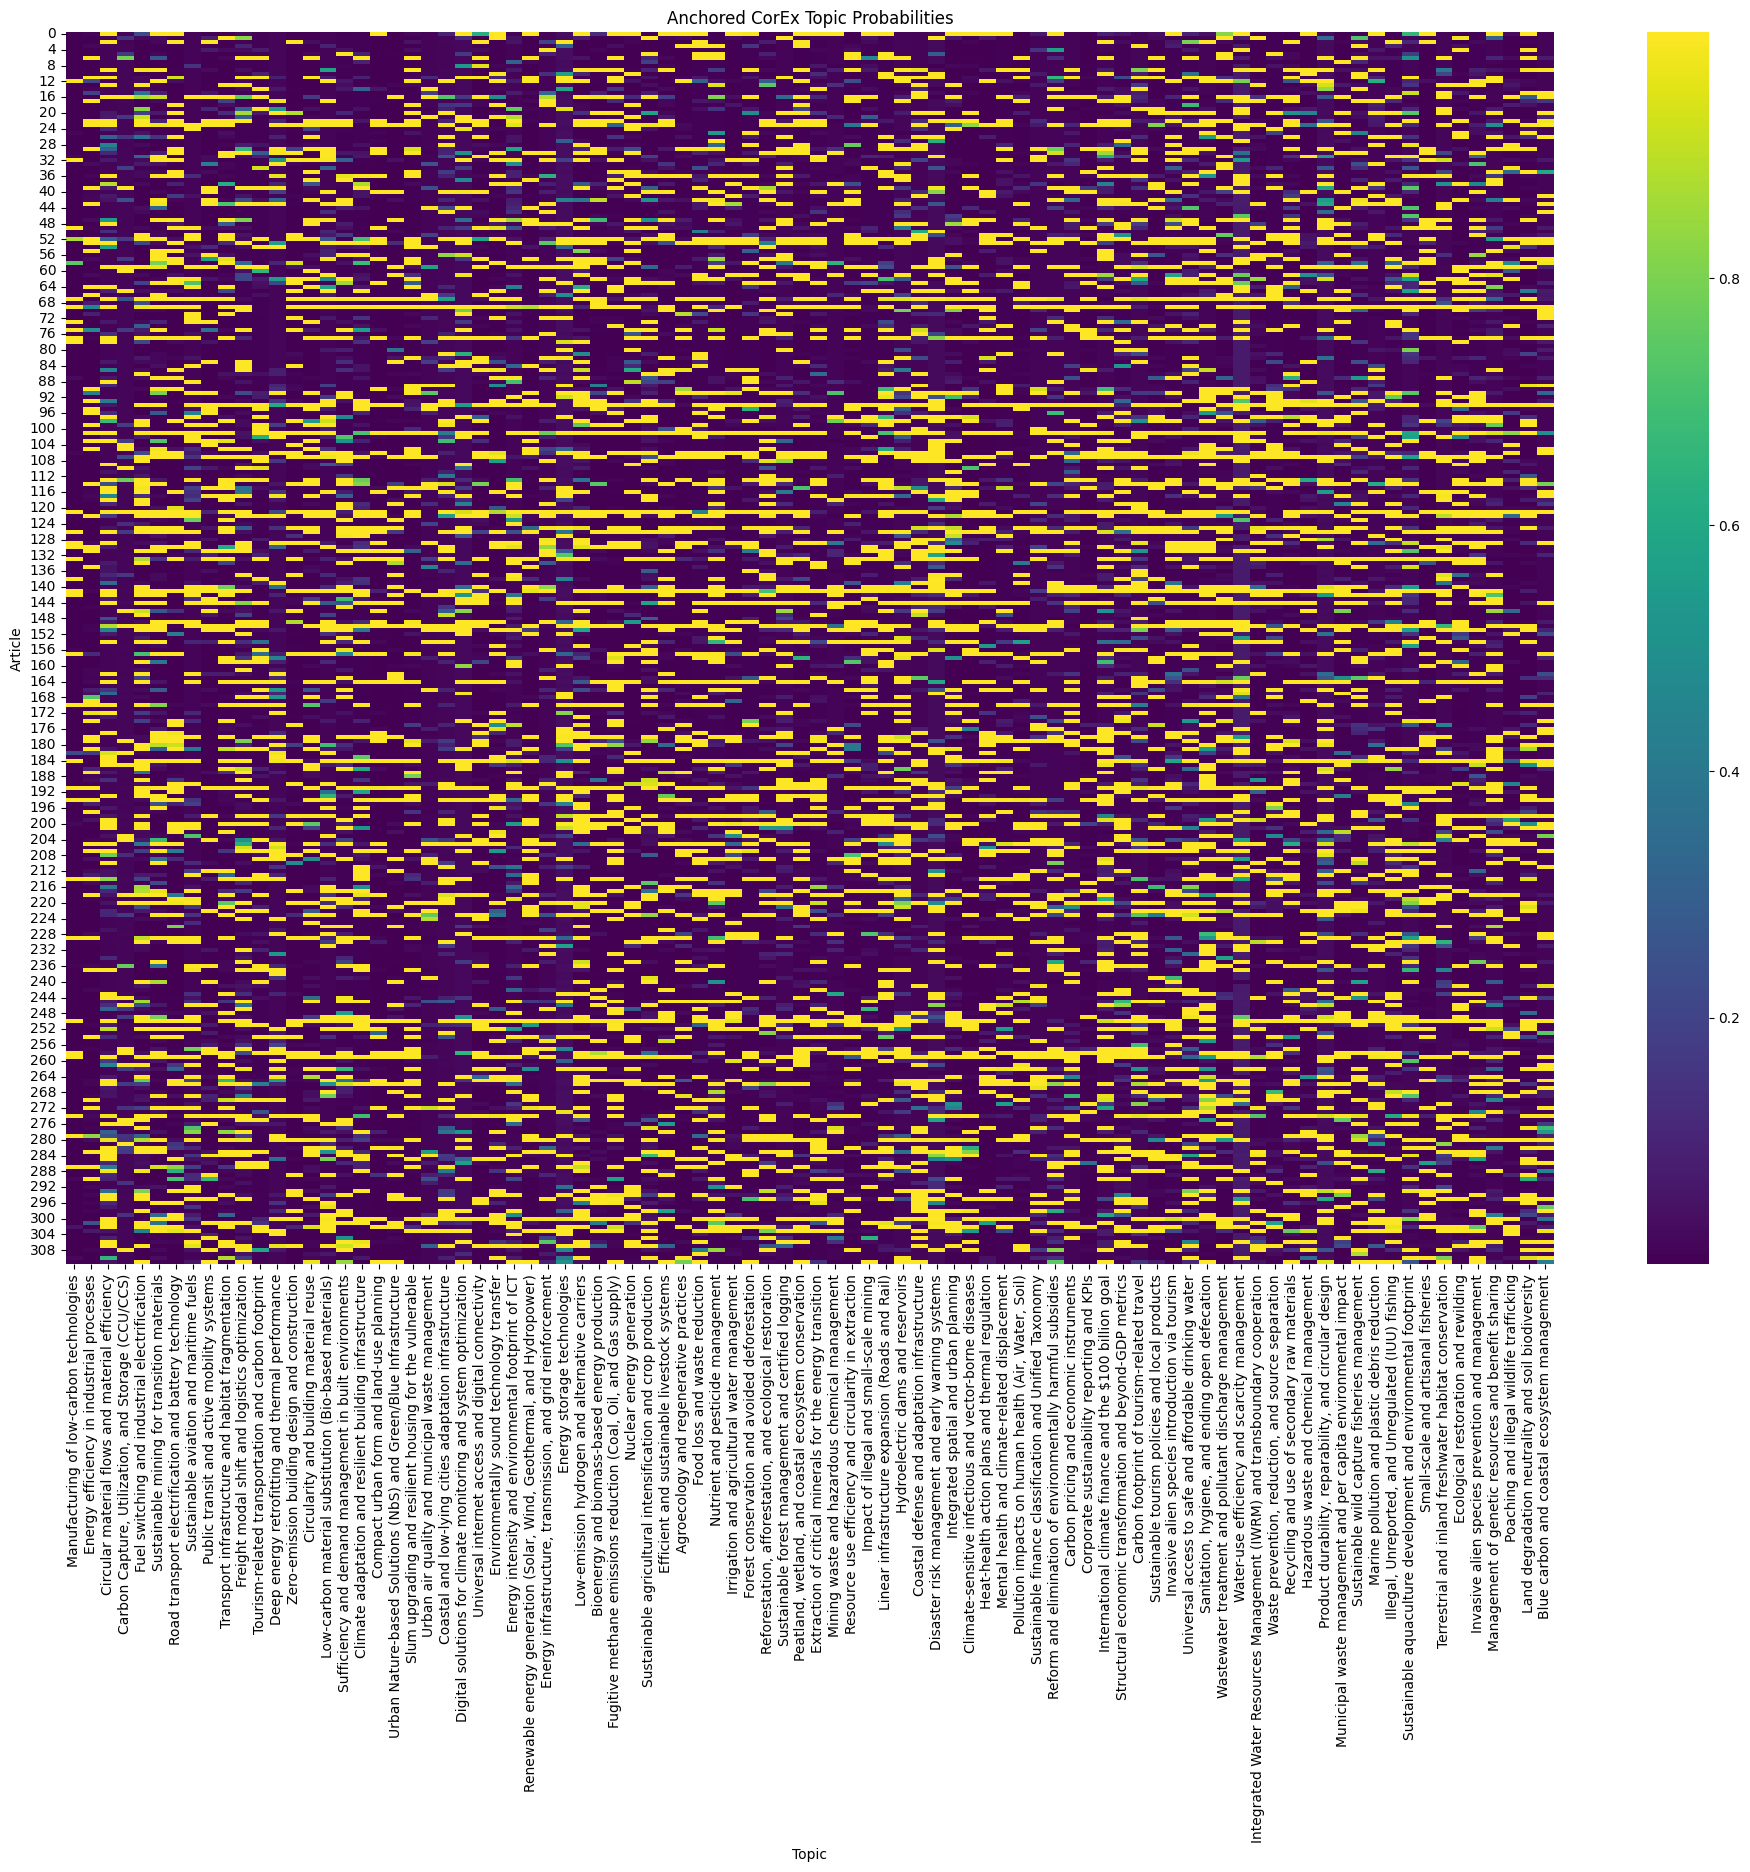

In [18]:
# Visualizing topics in each article

labels = model.labels          #0/1
probs  = model.p_y_given_x      #probabilities

for i, name in enumerate(topic_names):
    df[f"CorEx_{name}_label"] = labels[:, i]
    df[f"CorEx_{name}_prob"]  = probs[:, i]

plt.figure(figsize=(24, 16))
sns.heatmap(probs, cmap="viridis", xticklabels=topic_names)
plt.xlabel("Topic")
plt.ylabel("Article")
plt.title("Anchored CorEx Topic Probabilities")
plt.show()

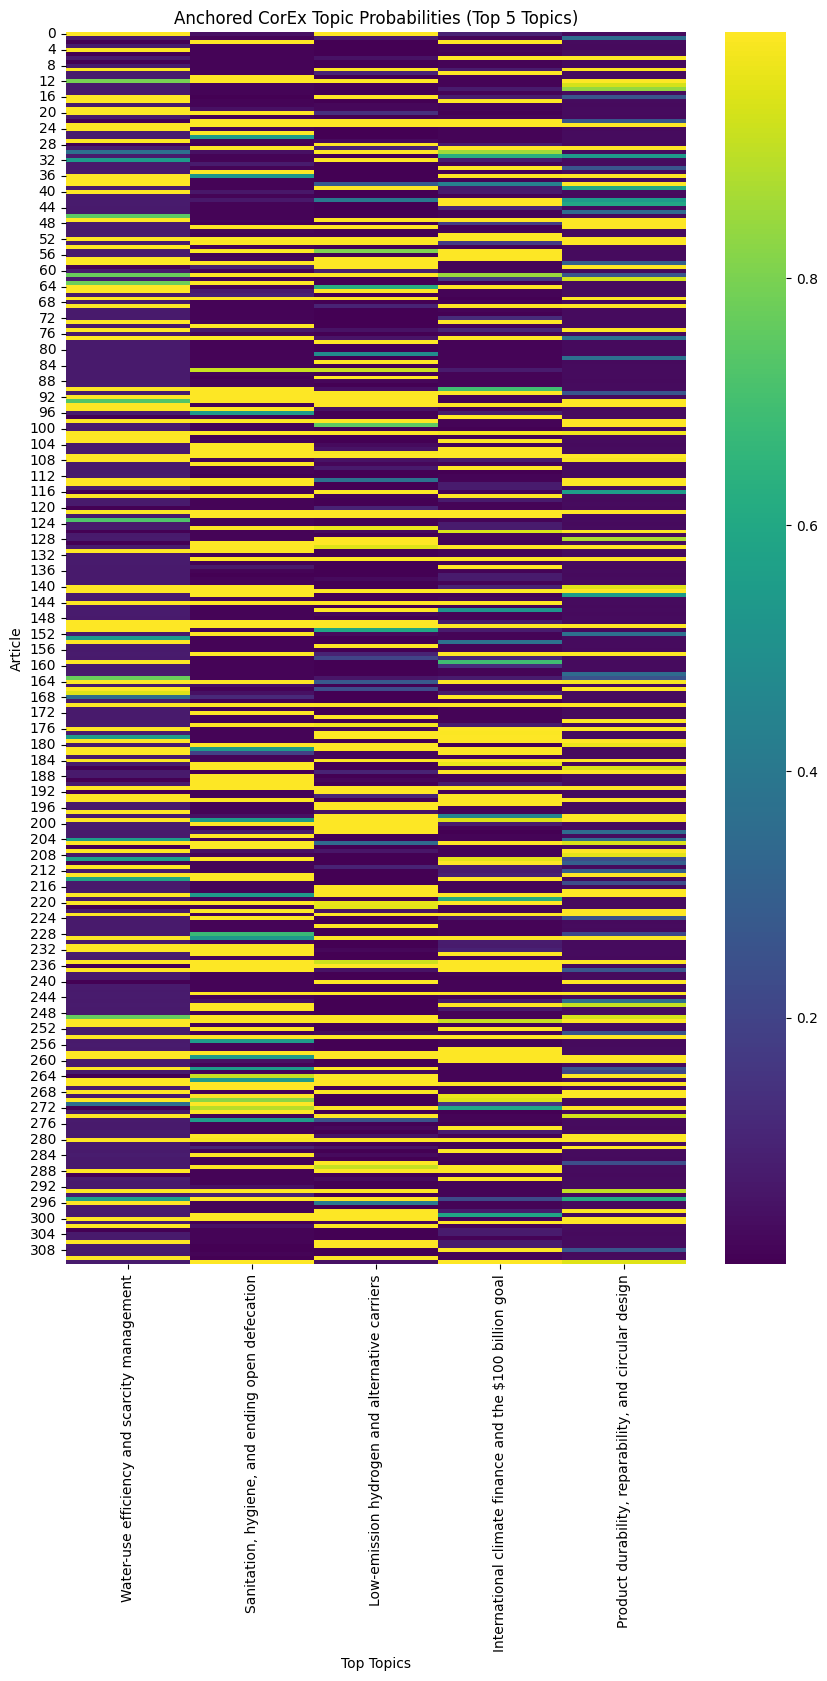

In [19]:
# Visualizing top topics across all articles

topic_means = probs.mean(axis=0)

N = 5 # number of top topics to show
top_idx = topic_means.argsort()[::-1][:N]

probs_top = probs[:, top_idx]
topic_names_top = [topic_names[i] for i in top_idx]

plt.figure(figsize=(10, 16))
sns.heatmap(probs_top, cmap="viridis", xticklabels=topic_names_top)
plt.xlabel("Top Topics")
plt.ylabel("Article")
plt.title(f"Anchored CorEx Topic Probabilities (Top {N} Topics)")
plt.show()


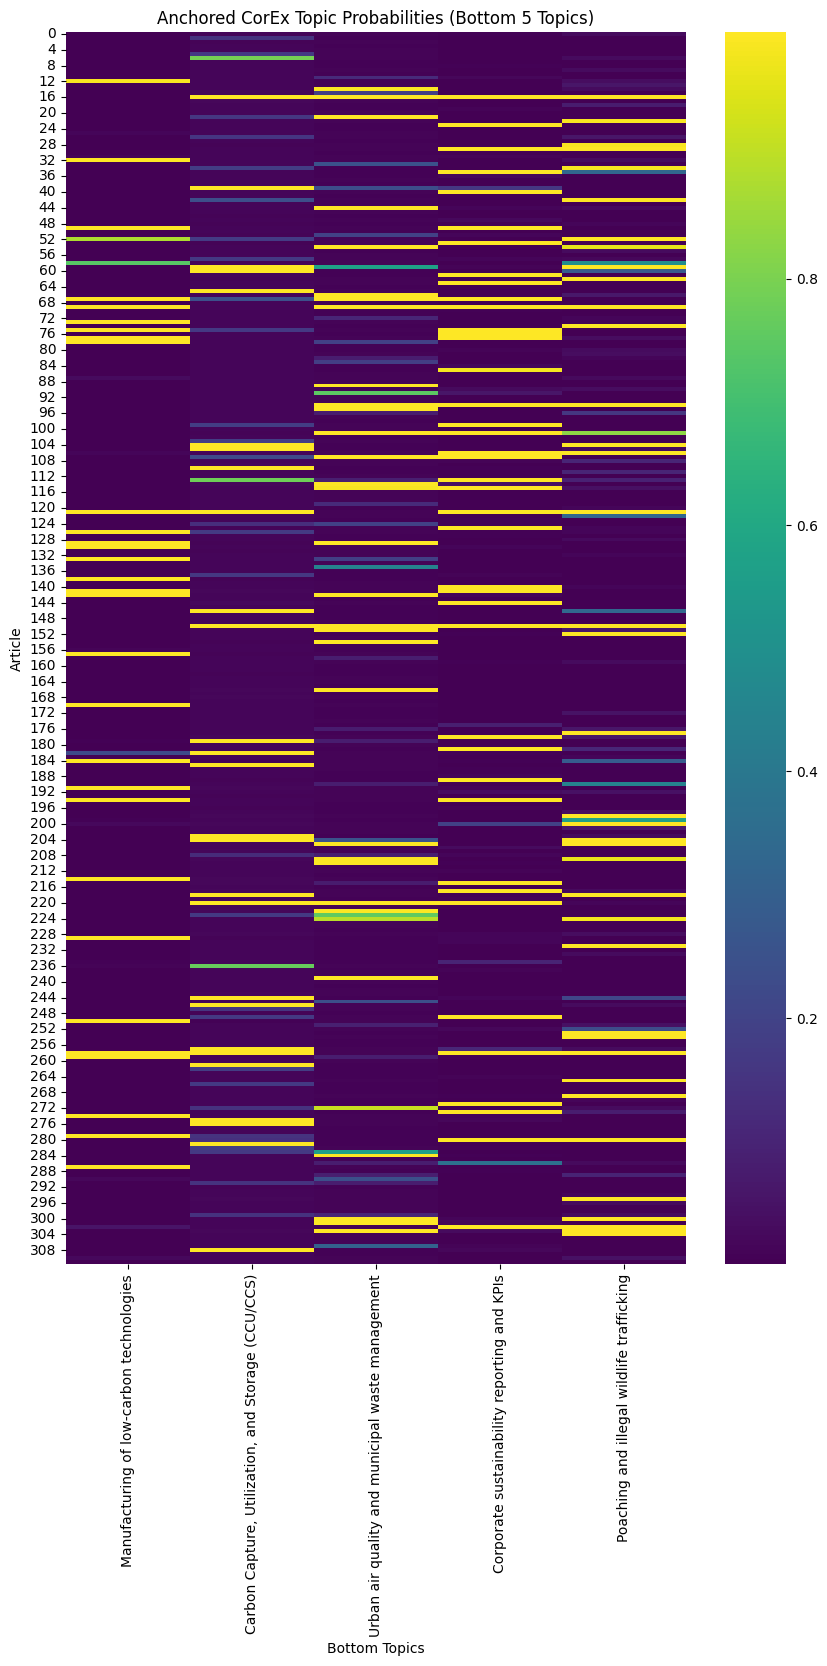

In [20]:
# Visualizing bottom topics across all articles

topic_means = probs.mean(axis=0)

N = 5 # number of bottom topics to show
bottom_idx = topic_means.argsort()[:N]   # smallest values first


probs_bottom = probs[:, bottom_idx]
topic_names_bottom = [topic_names[i] for i in bottom_idx]

plt.figure(figsize=(10, 16))
sns.heatmap(probs_bottom, cmap="viridis", xticklabels=topic_names_bottom)
plt.xlabel("Bottom Topics")
plt.ylabel("Article")
plt.title(f"Anchored CorEx Topic Probabilities (Bottom {N} Topics)")
plt.show()


In [21]:
# post-treatment: assigning dominant topic to each article
probs = model.p_y_given_x

dominant_idx = probs.argmax(axis=1)
dominant_prob = probs.max(axis=1)

MIN_RELEVANCE = 0.50 # strict threshold for topic assignment

df["(Sub-Category)"] = [
    topic_names[idx] if prob >= MIN_RELEVANCE else "None"
    for idx, prob in zip(dominant_idx, dominant_prob)
]

C:\Users\jean-\AppData\Local\Temp\ipykernel_48764\4026888361.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["(Sub-Category)"] = [


In [25]:
# post-treatment: assigning keywords to each article

TOP_N = 5

topic_keywords = {}

for i, name in enumerate(topic_names):
    words_scores = model.get_topics(topic=i, n_words=TOP_N)
    top_words = [w[0] for w in words_scores]
    topic_keywords[name] = top_words

df["Key NLP words targets"] = df["(Sub-Category)"].map(
    lambda t: ", ".join(topic_keywords[t]) if t in topic_keywords else ""
)

In [26]:
# ensuring ArticleText remains intact. Done with help from ChatGPT4.0 after encountering errors

import re

def clean_article(text):
    if not isinstance(text, str):
        return ""

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Remove semicolons
    text = text.replace(";", " ")

    # Remove tabs
    text = text.replace("\t", " ")

    # Remove line breaks
    text = text.replace("\n", " ").replace("\r", " ")

    # Remove multiple spaces
    text = re.sub(r"\s+", " ", text)

    # Strip leading/trailing spaces
    text = text.strip()

    return text

df["ArticleText"] = df["ArticleText"].astype(str).apply(clean_article)

In [27]:
# exporting to .csv for tagging postTreatment

clean_df = df[["URL", "ArticleText", "(Sub-Category)", "Key NLP words targets"]]

clean_df.to_csv(
    "PostTreatment_dataset_CorEx.csv",
    sep=";",
    index=False,
    quoting=1, # ensuring ArticleText remains intact. Done with help from ChatGPT4.0 after encountering errors
    escapechar="\\"
)

# Conclusion

In this notebook, we:

- Used a directed CorEx model using our smaller dataset (Snopes) and the robust seed of topics.
- Visualized outputs with additional native graphic generation capabilities.
- Exported our results to .csv: Notebooks\PostTreatment_dataset_CorEx.csv

This methodology be be operationalized over time and generalized to offer insights in other important news topics, such as health, politics, technology, etc. present in the loaded datasets and providing a tailored list of topics& keywords to the ML model. The commented settings can also be adapted to provide more meaningful insights for other datasets.